# PubMatrix — Query & Visualise

Build a pairwise publication co-occurrence matrix with `pubmatrix()`, then visualise it as a heatmap.

Reference: Becker et al. (2003) BMC Bioinformatics 4:61. https://doi.org/10.1186/1471-2105-4-61

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from pubmatrix import pubmatrix, pubmatrix_from_file, plot_pubmatrix_heatmap, pubmatrix_heatmap

## Basic usage

`A` is the list of column terms, `B` the rows.

In [2]:
A = ["WNT1", "WNT2", "CTNNB1"]
B = ["obesity", "diabetes", "cancer"]

result = pubmatrix(A=A, B=B)
result

Querying NCBI: 100%|███████████████████████████████████████| 9/9 [00:03<00:00,  2.57query/s]


,WNT1,WNT2,CTNNB1
obesity,63,6,90
diabetes,118,18,267
cancer,1278,297,8363


## Using an API key

An NCBI API key raises the rate limit from 3 to 10 requests/second.
Get yours at https://account.ncbi.nlm.nih.gov/

In [3]:
# Uncomment and set your key:
# result = pubmatrix(A=A, B=B, api_key="YOUR_KEY_HERE")

## Date filtering

In [4]:
result_recent = pubmatrix(A=A, B=B, daterange=[2015, 2024])
result_recent

Querying NCBI: 100%|███████████████████████████████████████| 9/9 [00:05<00:00,  1.76query/s]


,WNT1,WNT2,CTNNB1
obesity,42,4,68
diabetes,89,11,179
cancer,579,136,4406


## PMC database

In [5]:
result_pmc = pubmatrix(A=A, B=B, database="pmc")
result_pmc

Querying NCBI: 100%|███████████████████████████████████████| 9/9 [00:03<00:00,  2.51query/s]


,WNT1,WNT2,CTNNB1
obesity,2765,1013,4904
diabetes,4396,1610,7073
cancer,12695,5089,29362


## Export to CSV (with PubMed hyperlinks)

In [6]:
result_exported = pubmatrix(A=A, B=B, outfile="output", export_format="csv")

Querying NCBI: 100%|███████████████████████████████████████| 9/9 [00:03<00:00,  2.52query/s]

Saved CSV to output.csv


## Load terms from file

File format:
```
term_A1
term_A2
#
term_B1
term_B2
```

In [7]:
# Write a sample file
sample_terms = """WNT1
WNT2
#
obesity
diabetes
"""
with open("sample_terms.txt", "w") as f:
    f.write(sample_terms)

result_from_file = pubmatrix_from_file("sample_terms.txt")
result_from_file

Querying NCBI: 100%|███████████████████████████████████████| 4/4 [00:01<00:00,  2.49query/s]


,WNT1,WNT2
obesity,63,6
diabetes,118,18


In [8]:
import os
os.remove("sample_terms.txt")

---

## Heatmap visualisation

Use `pubmatrix_heatmap()` for a quick plot, or `plot_pubmatrix_heatmap()` for full control.

## Quick heatmap

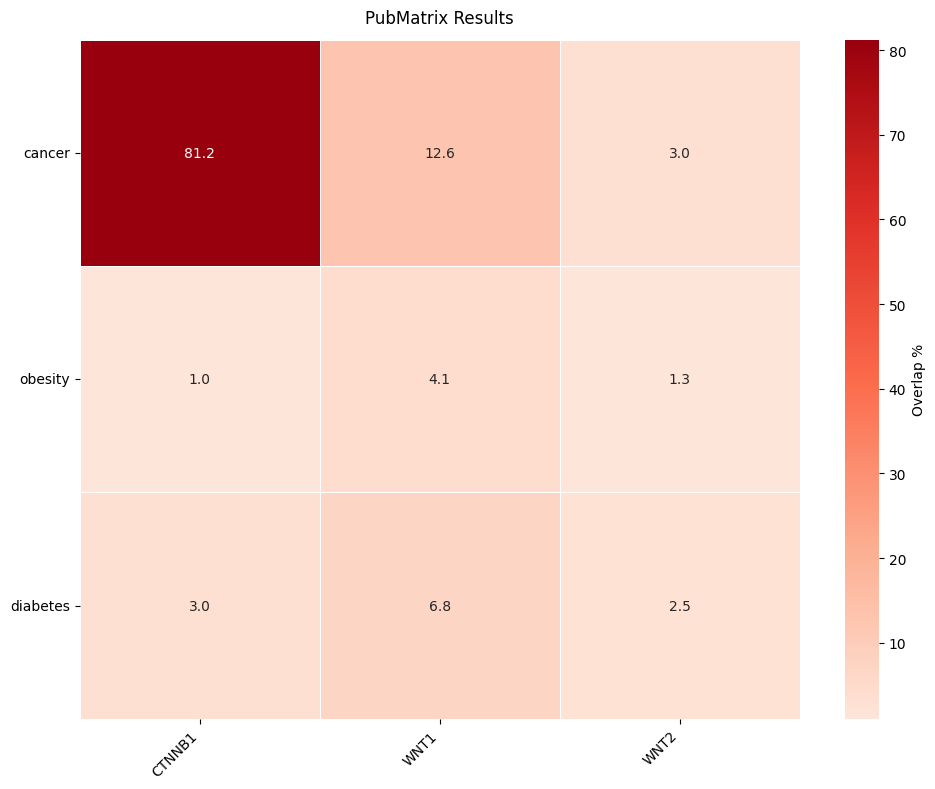

<Axes: title={'center': 'PubMatrix Results'}>

In [9]:
pubmatrix_heatmap(result)

## Full heatmap with all options

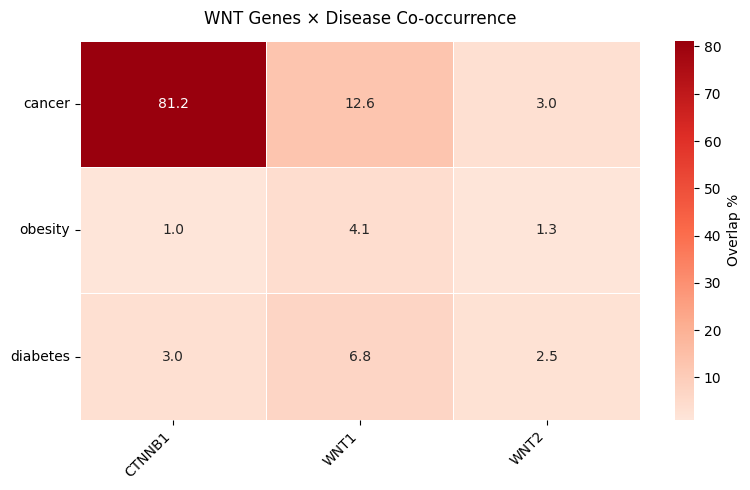

<Axes: title={'center': 'WNT Genes × Disease Co-occurrence'}>

In [10]:
plot_pubmatrix_heatmap(
    result,
    title="WNT Genes × Disease Co-occurrence",
    cluster_rows=True,
    cluster_cols=True,
    show_numbers=True,
    width=8,
    height=5,
)

## Custom colour palette

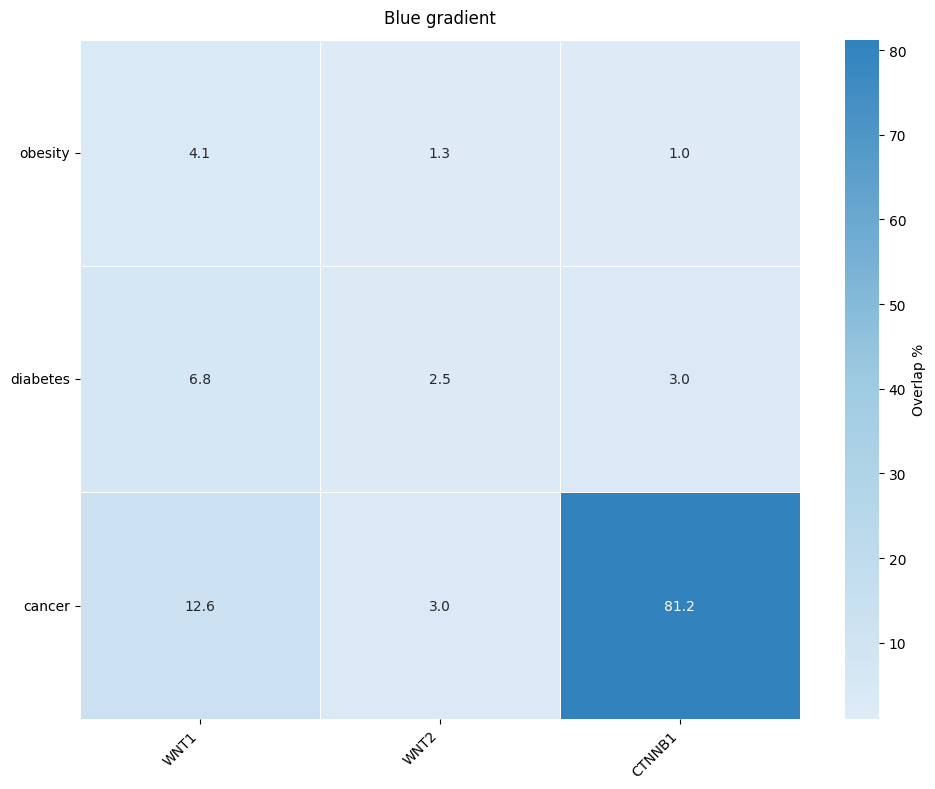

<Axes: title={'center': 'Blue gradient'}>

In [11]:
plot_pubmatrix_heatmap(
    result,
    title="Blue gradient",
    color_palette=["#deebf7", "#9ecae1", "#3182bd"],
    cluster_rows=False,
    cluster_cols=False,
)

## Save to PNG

Saved heatmap to heatmap_output.png


<Axes: title={'center': 'Saved Heatmap'}>

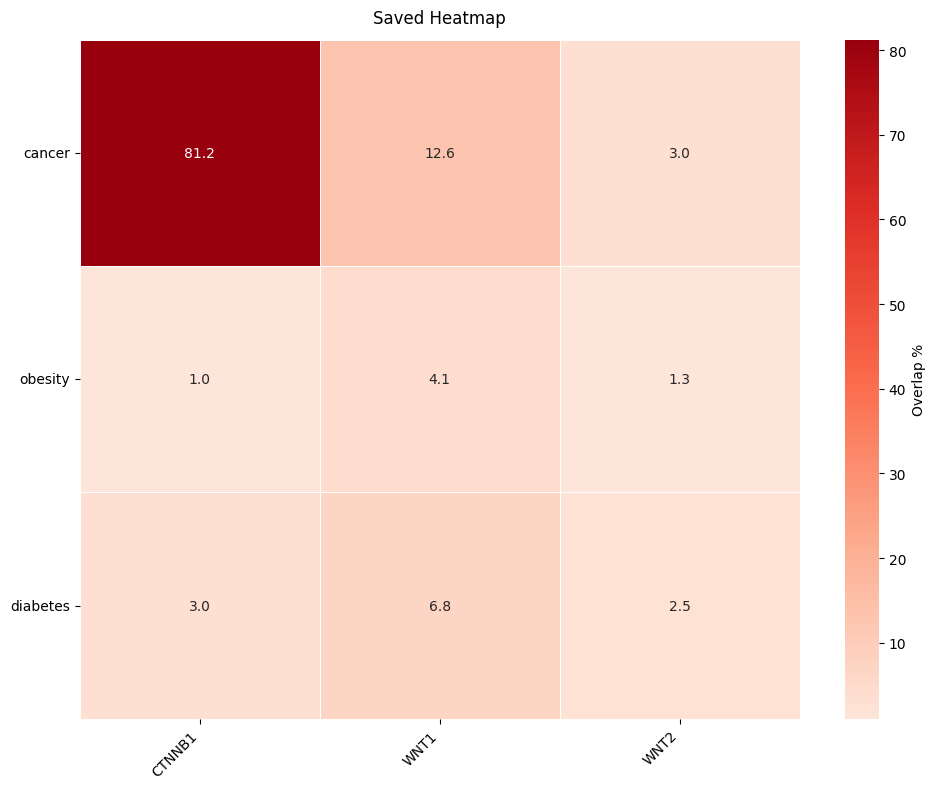

In [12]:
plot_pubmatrix_heatmap(
    result,
    title="Saved Heatmap",
    filename="heatmap_output.png",
)